In [1]:
import os

from flx.extractor.fixed_length_extractor import get_DeepPrint_TexMinu, DeepPrintExtractor


extractor: DeepPrintExtractor = get_DeepPrint_TexMinu(num_training_subjects=8000, num_dims=256)

MODEL_DIR: str = os.path.abspath("../models")
extractor.load_best_model(MODEL_DIR)

Loaded best model from /home/heitor/Misc/DeepPrint/fixed-length-fingerprint-extractors/models/best_model.pyt


In [2]:
import os

from flx.data.dataset import *
from flx.data.image_loader import MCYTCapacitiveLoader
from flx.data.transformed_image_loader import TransformedImageLoader
from flx.image_processing.binarization import LazilyAllocatedBinarizer
from flx.data.image_helpers import pad_and_resize_to_deepprint_input_size

DATASET_PATH: str = os.path.abspath("/storage/datasets/subsets/mcyt330dp/")

image_loader = TransformedImageLoader(
        images=MCYTCapacitiveLoader(DATASET_PATH),
        poses=None,
        transforms=[
            LazilyAllocatedBinarizer(5.0),
            pad_and_resize_to_deepprint_input_size,
        ],
    )

image_dataset: Dataset = Dataset(image_loader, image_loader.ids)

texture_embeddings, minutia_embeddings = extractor.extract(image_dataset)

Created IdentifierSet with 1000 subjects and a total of 12000 samples.


  0%|          | 0/750 [00:00<?, ?it/s]/home/heitor/miniforge3/envs/det/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: pin_memory_device is deprecated, the current accelerator will be used as the device,ignore pin_memory_device='cuda:0'.
  super().__init__(loader)
100%|██████████| 750/750 [11:53<00:00,  1.05it/s]


In [3]:
from flx.scripts.generate_benchmarks import create_verification_benchmark

NUM_IMPRESSIONS_PER_SUBJECT = 12
benchmark = create_verification_benchmark(
    subjects=list(range(image_dataset.num_subjects)),
    impressions_per_subject=list(range(NUM_IMPRESSIONS_PER_SUBJECT))
)

100%|██████████| 1000/1000 [00:00<00:00, 4234.34it/s]


In [4]:
from flx.benchmarks.matchers import CosineSimilarityMatcher
from flx.data.embedding_loader import EmbeddingLoader

# We concatenate texture and minutia embedding vectors
embeddings = EmbeddingLoader.combine(texture_embeddings, minutia_embeddings)
matcher = CosineSimilarityMatcher(EmbeddingLoader.combine(texture_embeddings, minutia_embeddings))

results = benchmark.run(matcher)

print(f"Equal-Error-Rate: {results.get_equal_error_rate()}")

Created IdentifierSet with 1000 subjects and a total of 12000 samples.
Created IdentifierSet with 1000 subjects and a total of 12000 samples.
Created IdentifierSet with 1000 subjects and a total of 12000 samples.
Created IdentifierSet with 1000 subjects and a total of 12000 samples.
Created IdentifierSet with 1000 subjects and a total of 12000 samples.
Created IdentifierSet with 1000 subjects and a total of 12000 samples.


100%|██████████| 210000/210000 [00:00<00:00, 288714.97it/s]

Equal-Error-Rate: 0.004833333333333334


/home/heitor/Misc/DeepPrint/fixed-length-fingerprint-extractors/flx/visualization/det_curve_plotting/DET.py:667: SyntaxWarning: invalid escape sequence '\%'
  mpl.xlabel(mpl.axes().get_xlabel().replace("%", "\%"))
/home/heitor/Misc/DeepPrint/fixed-length-fingerprint-extractors/flx/visualization/det_curve_plotting/DET.py:668: SyntaxWarning: invalid escape sequence '\%'
  mpl.ylabel(mpl.axes().get_ylabel().replace("%", "\%"))


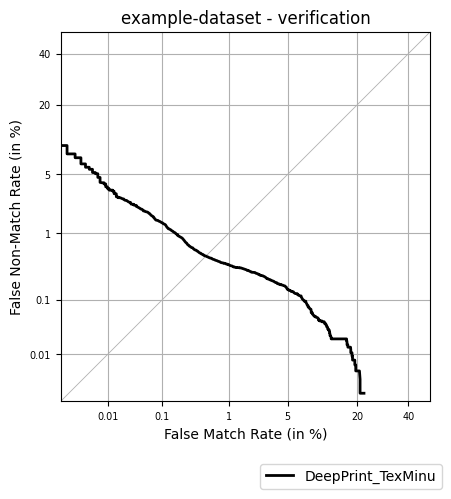

In [5]:
from flx.visualization.plot_DET_curve import plot_verification_results

figure_path = "DET_curve"

# Lists are used to allow for multiple models to be plotted in the same figure
plot_verification_results(figure_path, results=[results], model_labels=["DeepPrint_TexMinu"], plot_title="example-dataset - verification")

In [6]:
embeddings.save('.')

In [7]:
embeddings.load('.')